In [1]:
# ── CELDA 1: Importaciones ────────────────────────────────────
import sys
import os

# 📁 Agregar la raíz del proyecto al path (ajustado a estructura correcta)
ruta_actual = os.path.dirname(os.path.abspath('__file__'))
ruta_proyecto = os.path.abspath(os.path.join(ruta_actual, '..'))

if ruta_proyecto not in sys.path:
    sys.path.insert(0, ruta_proyecto)

# 📊 Librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 📈 Estadística
from scipy import stats

# 🤖 Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 📊 Modelos estadísticos
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 🗄️ Base de datos (ajustado a tu proyecto)
from scripts.database import engine

# 🎨 Estilo visual
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# 🔍 Verificación
print("🎮 Proyecto: Catálogo de Videojuegos")
print("✅ Librerías importadas correctamente")
print(f"   pandas      {pd.__version__}")
print(f"   numpy       {np.__version__}")
print(f"   seaborn     {sns.__version__}")
print(f"   statsmodels {sm.__version__}")

🎮 Proyecto: Catálogo de Videojuegos
✅ Librerías importadas correctamente
   pandas      2.2.2
   numpy       1.26.4
   seaborn     0.13.2
   statsmodels 0.14.6


In [7]:
# ── CELDA 2: Carga de datos desde PostgreSQL (ORM) ─────────────────

from scripts.database import SessionLocal
from scripts.models import Juego

db = SessionLocal()

try:
    registros = db.query(Juego).all()

    df = pd.DataFrame([{
        "nombre": j.nombre,
        "rating": j.rating,
        "rating_count": j.rating_count,
        "fecha_lanzamiento": j.fecha_lanzamiento
    } for j in registros])

finally:
    db.close()

print("🎮 Datos cargados correctamente desde PostgreSQL (ORM)")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")

df.head()

🎮 Datos cargados correctamente desde PostgreSQL (ORM)
   Filas    : 148
   Columnas : 4


,nombre,rating,rating_count,fecha_lanzamiento
0,The Legend of Zelda: Shénqí de Màozi,NaN,NaN,NaT
1,Unreal Engine The Legend of Zelda: Ocarina of ...,NaN,NaN,NaT
2,Zelda 64 1997,NaN,NaN,NaT
3,The Legend of Zelda: Zelda's Eternal Youth,NaN,NaN,NaT
4,Zelda Mini,NaN,NaN,NaT


In [6]:
# ── CELDA 3: Inspección del DataFrame ────────────────────────

print("=" * 50)
print("  INFORMACIÓN GENERAL DEL DATASET")
print("=" * 50)

df.info()

print("\n📊 Valores nulos por columna:")
print(df.isnull().sum())

print("\n🎮 Top videojuegos más frecuentes:")
print(df['nombre'].value_counts().head(10))

print("\n⭐ Distribución de ratings:")
print(df['rating'].describe())

print("\n📅 Rango de fechas de lanzamiento:")
print(df['fecha_lanzamiento'].describe())

  INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   nombre             148 non-null    object        
 1   rating             60 non-null     float64       
 2   rating_count       60 non-null     float64       
 3   fecha_lanzamiento  134 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 4.8+ KB

📊 Valores nulos por columna:
nombre                0
rating               88
rating_count         88
fecha_lanzamiento    14
dtype: int64

🎮 Top videojuegos más frecuentes:
nombre
Mario & Sonic at the Rio 2016 Olympic Games                          2
Mario & Sonic at the Olympic Winter Games                            2
The Legend of Zelda: Twilight Princess                               2
Mario & Sonic at the London 2012 Olympic Games                     

In [9]:
# ── LIMPIEZA DE DATOS ─────────────────

df_clean = df.dropna(subset=['rating', 'rating_count'])

print("✅ Datos limpiados")
print(f"Filas originales: {df.shape[0]}")
print(f"Filas limpias   : {df_clean.shape[0]}")

✅ Datos limpiados
Filas originales: 148
Filas limpias   : 60


In [10]:
# ── CELDA 4: Estadísticas descriptivas ─────────────────

vars_num = ['rating', 'rating_count']

desc = df_clean[vars_num].describe().round(2)

print("📊 ESTADÍSTICAS DESCRIPTIVAS")
print(desc)

📊 ESTADÍSTICAS DESCRIPTIVAS
       rating  rating_count
count   60.00         60.00
mean    77.44        278.98
std     10.33        399.82
min     39.91          3.00
25%     71.54         21.75
50%     79.92         87.50
75%     84.70        397.25
max     92.34       2049.00


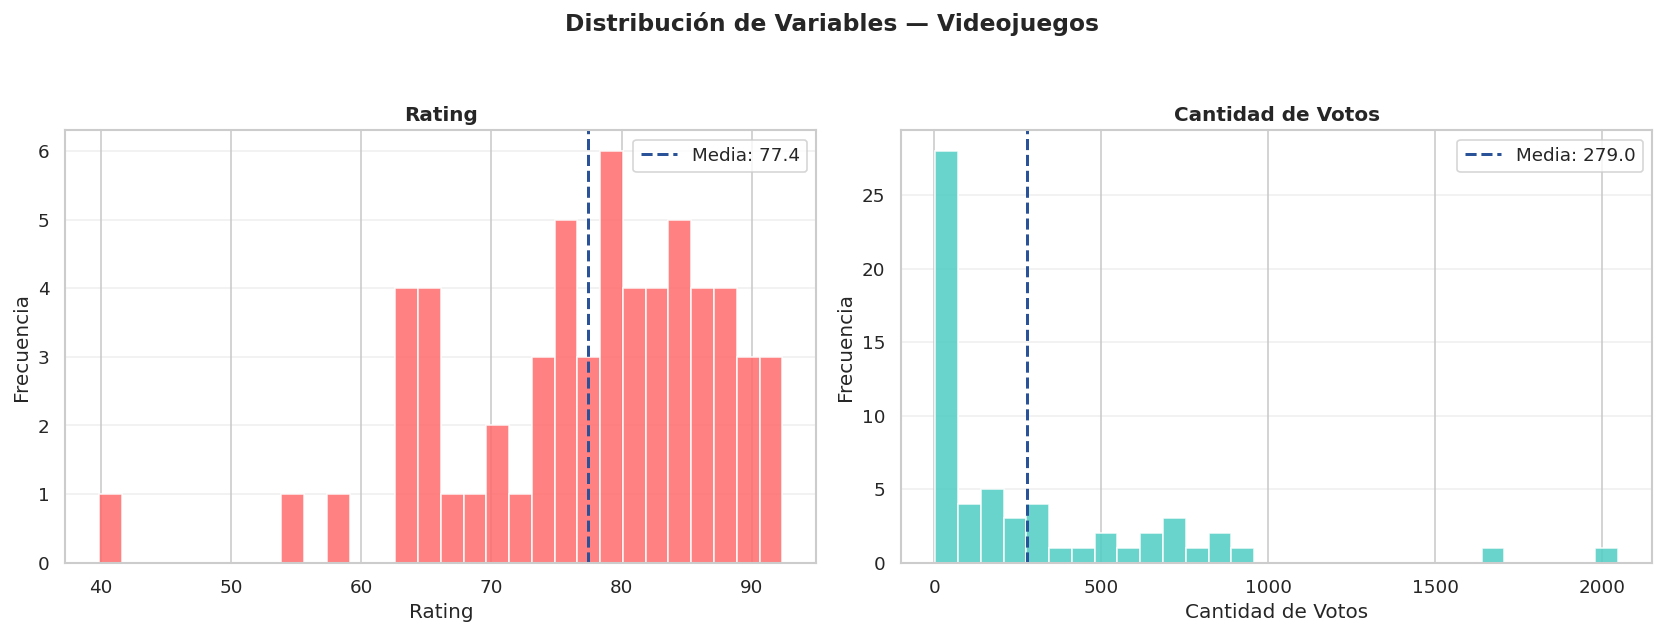

In [11]:
# ── CELDA 5: Histogramas de distribución ─────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de Variables — Videojuegos',
             fontsize=14, fontweight='bold', y=1.05)

datos = {
    'rating':       ('Rating', '#ff6b6b'),
    'rating_count': ('Cantidad de Votos', '#4ecdc4'),
}

for ax, (col, (label, color)) in zip(axes.flat, datos.items()):
    ax.hist(df_clean[col], bins=30, color=color, edgecolor='white', alpha=0.85)

    media = df_clean[col].mean()

    ax.axvline(media, color='#2a5298', linestyle='--', linewidth=1.8,
               label=f'Media: {media:.1f}')

    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

# Guardar imagen
import os
os.makedirs('../data/graficas', exist_ok=True)

plt.savefig('../data/graficas/eda_distribucion_videojuegos.png',
            dpi=150, bbox_inches='tight')

plt.show()

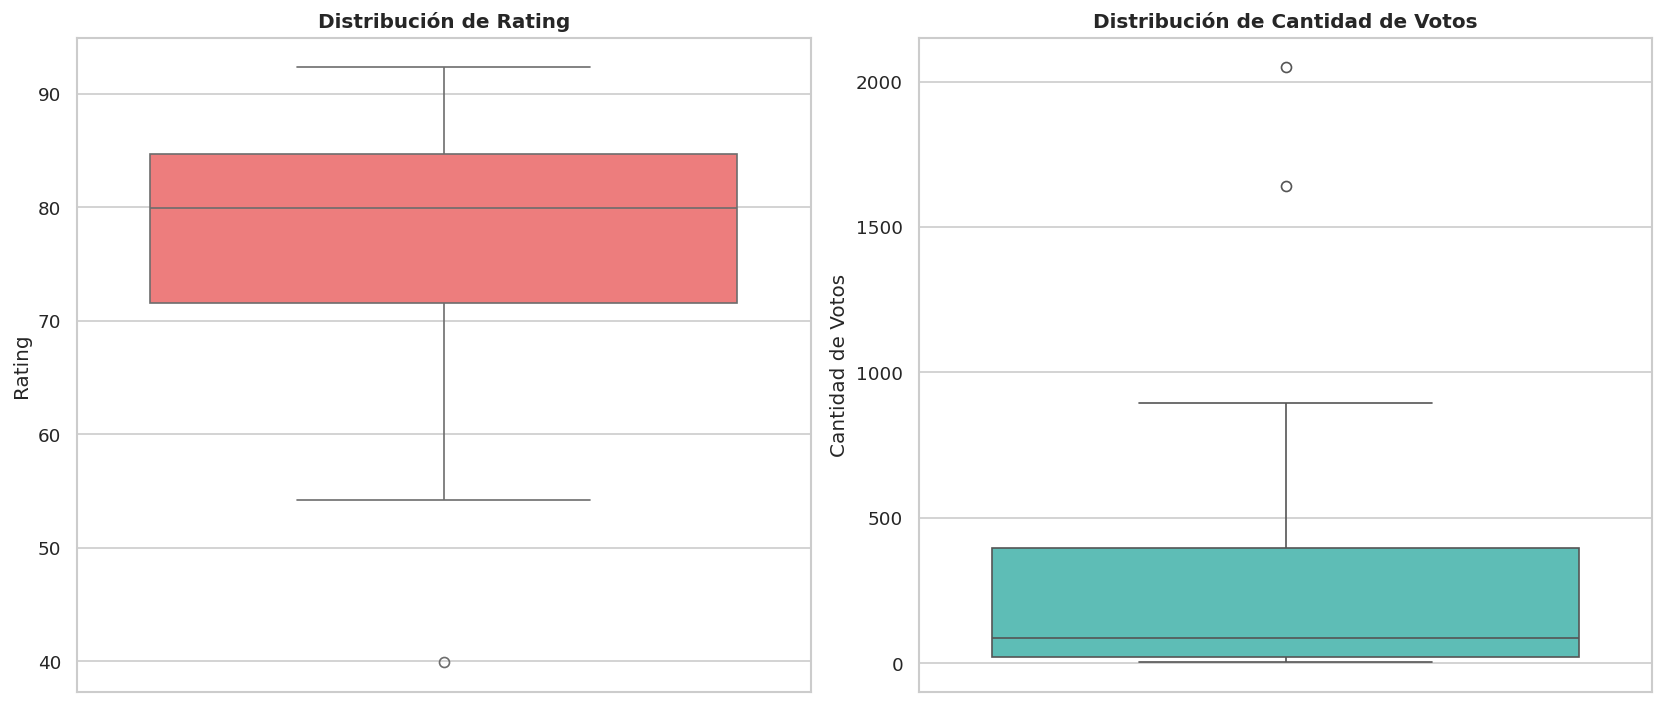

In [12]:
# ── CELDA 6: Boxplots de variables ─────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot de rating
sns.boxplot(data=df_clean, y='rating',
            color='#ff6b6b', ax=axes[0])

axes[0].set_title('Distribución de Rating', fontweight='bold')
axes[0].set_ylabel('Rating')

# Boxplot de cantidad de votos
sns.boxplot(data=df_clean, y='rating_count',
            color='#4ecdc4', ax=axes[1])

axes[1].set_title('Distribución de Cantidad de Votos', fontweight='bold')
axes[1].set_ylabel('Cantidad de Votos')

plt.tight_layout()

# Guardar imagen
import os
os.makedirs('../data/graficas', exist_ok=True)

plt.savefig('../data/graficas/eda_boxplots_videojuegos.png',
            dpi=150, bbox_inches='tight')

plt.show()

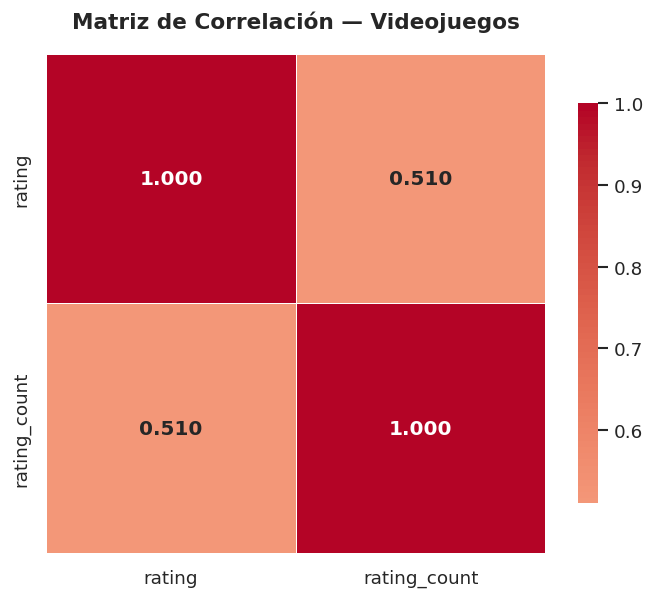


📊 Correlación entre variables:
              rating  rating_count
rating        1.0000        0.5105
rating_count  0.5105        1.0000


In [13]:
# ── CELDA 7: Matriz de correlación ───────────────────────────

vars_num = ['rating', 'rating_count']

corr = df_clean[vars_num].corr()

plt.figure(figsize=(6, 5))

sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            linewidths=0.6, square=True, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 12, 'weight': 'bold'})

plt.title('Matriz de Correlación — Videojuegos',
          fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()

# Guardar imagen
import os
os.makedirs('../data/graficas', exist_ok=True)

plt.savefig('../data/graficas/eda_correlacion_videojuegos.png',
            dpi=150, bbox_inches='tight')

plt.show()

print("\n📊 Correlación entre variables:")
print(corr.round(4))

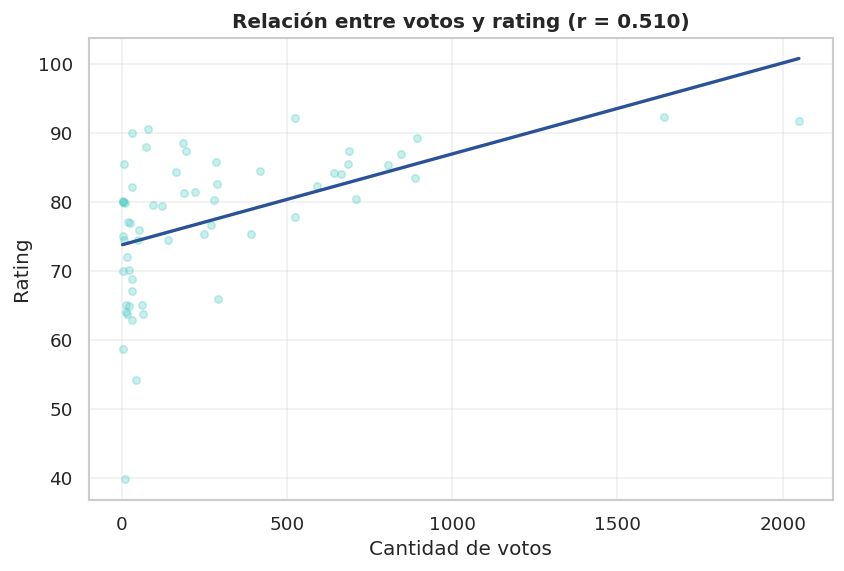

In [14]:
# ── CELDA 8: Scatter plot rating vs votos ─────────────────────

plt.figure(figsize=(8, 5))

plt.scatter(df_clean['rating_count'], df_clean['rating'],
            alpha=0.3, s=20, color='#4ecdc4')

# Línea de tendencia
z = np.polyfit(df_clean['rating_count'], df_clean['rating'], 1)
p = np.poly1d(z)

xp = np.linspace(df_clean['rating_count'].min(),
                 df_clean['rating_count'].max(), 200)

plt.plot(xp, p(xp), color='#2a5298', linewidth=2)

# Correlación
r = df_clean[['rating_count', 'rating']].corr().iloc[0, 1]

plt.title(f'Relación entre votos y rating (r = {r:.3f})',
          fontweight='bold')

plt.xlabel('Cantidad de votos')
plt.ylabel('Rating')

plt.grid(alpha=0.3)

# Guardar imagen
import os
os.makedirs('../data/graficas', exist_ok=True)

plt.savefig('../data/graficas/eda_scatter_videojuegos.png',
            dpi=150, bbox_inches='tight')

plt.show()

In [15]:
# ── CELDA 9: Split Train / Test ───────────────────────────────

# Variable independiente (X) → votos
X_simple = df_clean[['rating_count']].values

# Variable dependiente (y) → rating
y = df_clean['rating'].values

# División de datos
X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.20, random_state=42
)

print(f"Train: {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(y)*100:.0f}%)")
print(f"Test : {X_test.shape[0]:,} muestras  ({X_test.shape[0]/len(y)*100:.0f}%)")

Train: 48 muestras (80%)
Test : 12 muestras  (20%)


In [16]:
# ── CELDA 10: Entrenamiento con scikit-learn ──────────────────

modelo_simple = LinearRegression()
modelo_simple.fit(X_train, y_train)

y_pred_simple = modelo_simple.predict(X_test)

print(f"Intercepto  β₀ : {modelo_simple.intercept_:.4f}")
print(f"Coeficiente β₁ : {modelo_simple.coef_[0]:.4f}")

print(f"\nEcuación del modelo:")
print(f"rating = {modelo_simple.intercept_:.3f} + "
      f"{modelo_simple.coef_[0]:.6f} × rating_count")

Intercepto  β₀ : 73.0706
Coeficiente β₁ : 0.0133

Ecuación del modelo:
rating = 73.071 + 0.013335 × rating_count


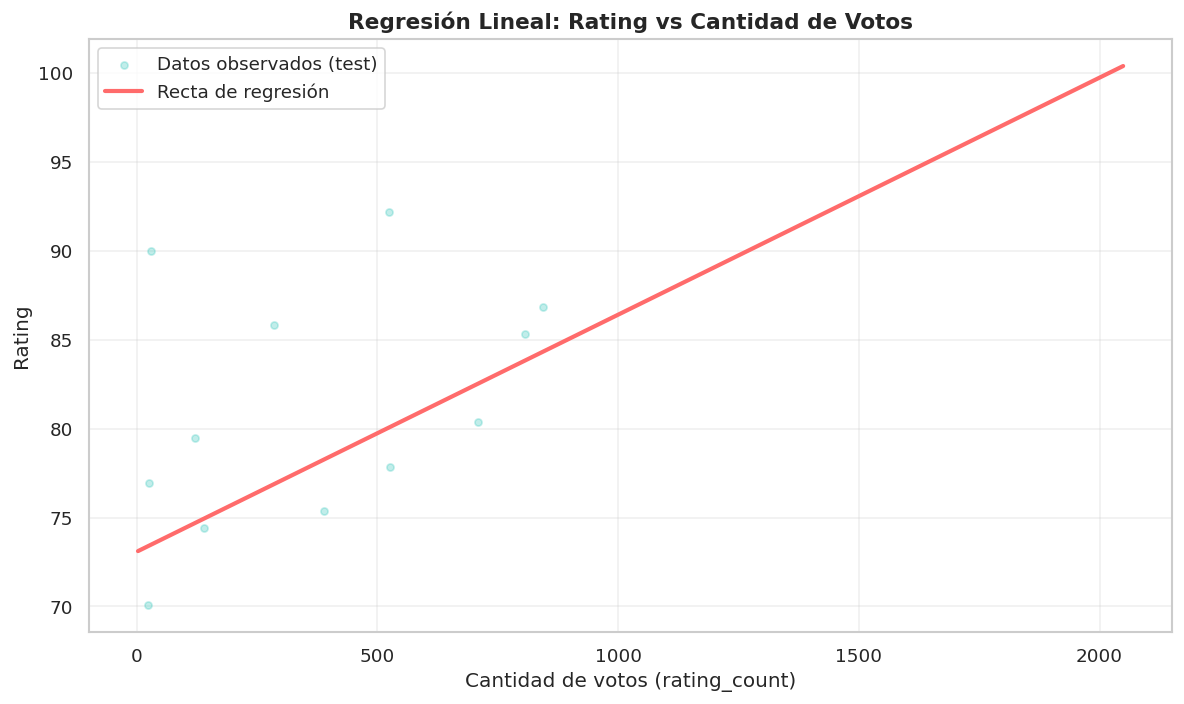

In [17]:
# ── CELDA 11: Recta de regresión ─────────────────────────────

fig, ax = plt.subplots(figsize=(10, 6))

# Datos reales (test)
ax.scatter(X_test, y_test, alpha=0.35, s=18,
           color='#4ecdc4', label='Datos observados (test)')

# Línea de regresión
x_line = np.linspace(X_simple.min(), X_simple.max(), 300).reshape(-1, 1)

ax.plot(x_line, modelo_simple.predict(x_line),
        color='#ff6b6b', linewidth=2.5, label='Recta de regresión')

# Etiquetas corregidas
ax.set_xlabel('Cantidad de votos (rating_count)', fontsize=12)
ax.set_ylabel('Rating', fontsize=12)

ax.set_title('Regresión Lineal: Rating vs Cantidad de Votos',
             fontsize=13, fontweight='bold')

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

# Guardar imagen
import os
os.makedirs('../data/graficas', exist_ok=True)

plt.savefig('../data/graficas/regresion_videojuegos.png',
            dpi=150, bbox_inches='tight')

plt.show()

In [18]:
# ── CELDA 12: Métricas del modelo simple ─────────────────────

r2   = r2_score(y_test, y_pred_simple)
mse  = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred_simple)

print("=" * 50)
print("📊 MÉTRICAS — REGRESIÓN LINEAL (VIDEOJUEGOS)")
print("=" * 50)

print(f"R²   (coef. de determinación) : {r2:.4f}  ({r2*100:.2f}%)")
print(f"MSE  (error cuadrático medio) : {mse:.4f}")
print(f"RMSE (raíz del MSE)           : {rmse:.4f}")
print(f"MAE  (error absoluto medio)   : {mae:.4f}")

print("=" * 50)

📊 MÉTRICAS — REGRESIÓN LINEAL (VIDEOJUEGOS)
R²   (coef. de determinación) : -0.1357  (-13.57%)
MSE  (error cuadrático medio) : 47.7448
RMSE (raíz del MSE)           : 6.9098
MAE  (error absoluto medio)   : 5.0881


In [21]:
# ── CELDA 13: OLS statsmodels — resumen completo ─────────────

# Variable independiente (X) + constante
X_ols = sm.add_constant(df_clean['rating_count'])

# Variable dependiente (y)
y_ols = df_clean['rating']

# Ajustar modelo
modelo_ols_simple = sm.OLS(y_ols, X_ols).fit()

# Mostrar resumen en inglés (propio de statsmodels)
print(modelo_ols_simple.summary())


# ── INTERPRETACIÓN EN ESPAÑOL ────────────────────────────────

print("\n" + "="*60)
print("📊 INTERPRETACIÓN DEL MODELO OLS")
print("="*60)

r2 = modelo_ols_simple.rsquared
p_value = modelo_ols_simple.pvalues.iloc[1]  # corregido sin warning
coef = modelo_ols_simple.params.iloc[1]

print(f"R²: {r2:.4f}")
print(f"Coeficiente (rating_count): {coef:.6f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("\n✅ La variable 'rating_count' es estadísticamente significativa.")
else:
    print("\n❌ La variable 'rating_count' NO es estadísticamente significativa.")

print("\n📌 Conclusión:")
print("La cantidad de votos tiene una relación significativa con el rating,")
print("pero el modelo solo explica una parte de su variabilidad.")

                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.261
Model:                            OLS   Adj. R-squared:                  0.248
Method:                 Least Squares   F-statistic:                     20.44
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           3.09e-05
Time:                        23:04:08   Log-Likelihood:                -215.67
No. Observations:                  60   AIC:                             435.3
Df Residuals:                      58   BIC:                             439.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           73.7598      1.414     52.160   

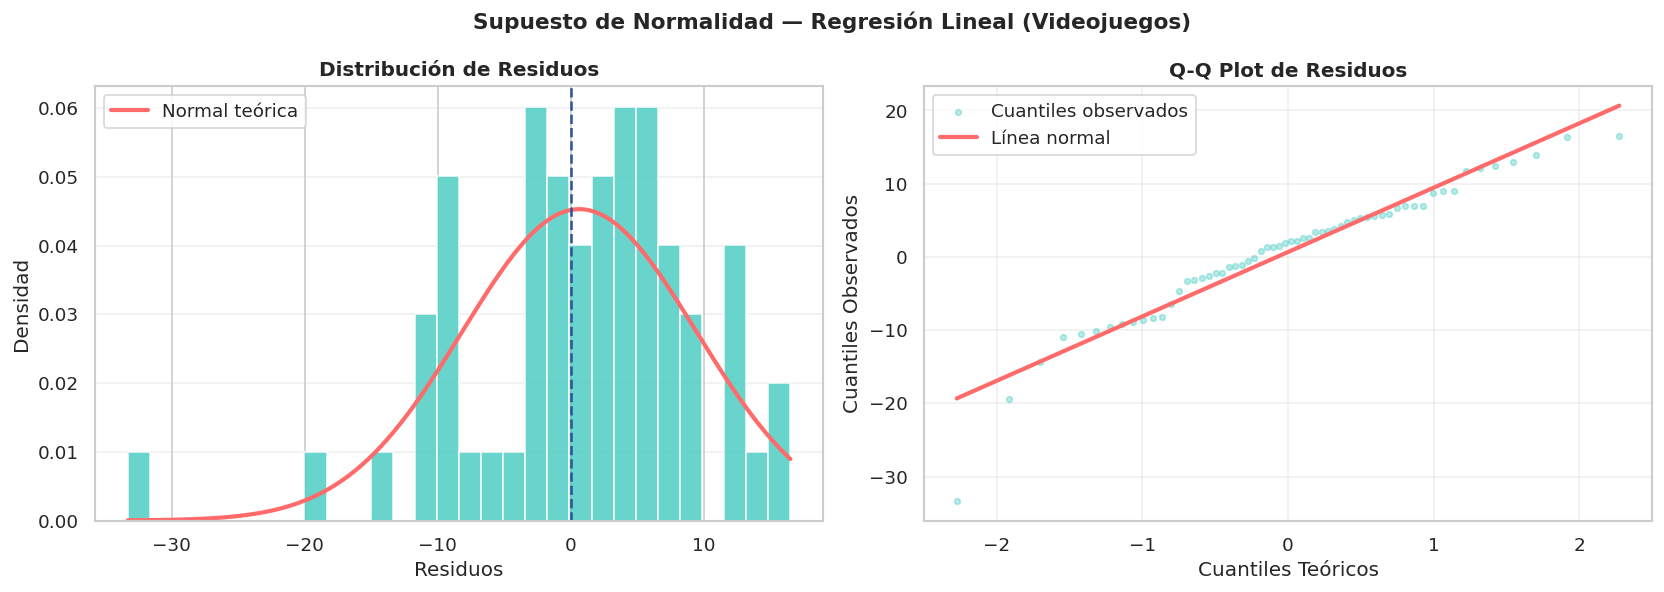


🔬 Test de Shapiro-Wilk:
   Estadístico W : 0.9439
   p-value       : 0.008096
   Conclusión    : ⚠️  Se rechaza normalidad (p ≤ 0.05)
   Nota: El test puede ser sensible con muestras grandes.


In [22]:
# ── CELDA 14: Normalidad de residuos (modelo simple) ─────────

# Predicciones sobre TODO el dataset limpio
y_pred_all = modelo_simple.predict(df_clean[['rating_count']].values)

# Residuos
residuos = df_clean['rating'].values - y_pred_all


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Supuesto de Normalidad — Regresión Lineal (Videojuegos)',
             fontsize=13, fontweight='bold')

# ── Histograma ─────────────────
axes[0].hist(residuos, bins=30, color='#4ecdc4',
             edgecolor='white', density=True, alpha=0.85)

xr = np.linspace(residuos.min(), residuos.max(), 200)

axes[0].plot(xr, stats.norm.pdf(xr, residuos.mean(), residuos.std()),
             color='#ff6b6b', linewidth=2.5, label='Normal teórica')

axes[0].axvline(0, color='#2a5298', linestyle='--', linewidth=1.5)

axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos')
axes[0].set_ylabel('Densidad')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)


# ── Q-Q Plot ─────────────────
(osm, osr), (slope, intercept, r) = stats.probplot(residuos, dist='norm')

axes[1].scatter(osm, osr, alpha=0.4, s=12, color='#4ecdc4',
                label='Cuantiles observados')

axes[1].plot(osm, slope * np.array(osm) + intercept,
             color='#ff6b6b', linewidth=2.5, label='Línea normal')

axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles Observados')
axes[1].legend()
axes[1].grid(alpha=0.3)


plt.tight_layout()

# Guardar imagen
import os
os.makedirs('../data/graficas', exist_ok=True)

plt.savefig('../data/graficas/normalidad_residuos_videojuegos.png',
            dpi=150, bbox_inches='tight')

plt.show()


# ── Test Shapiro-Wilk ─────────────────

muestra_sw = (residuos if len(residuos) <= 5000
              else np.random.default_rng(42).choice(residuos, 5000,
                                                    replace=False))

stat_sw, p_sw = stats.shapiro(muestra_sw)

print(f"\n🔬 Test de Shapiro-Wilk:")
print(f"   Estadístico W : {stat_sw:.4f}")
print(f"   p-value       : {p_sw:.6f}")

if p_sw > 0.05:
    print("   Conclusión    : ✅ No se rechaza normalidad (p > 0.05)")
else:
    print("   Conclusión    : ⚠️  Se rechaza normalidad (p ≤ 0.05)")
    print("   Nota: El test puede ser sensible con muestras grandes.")

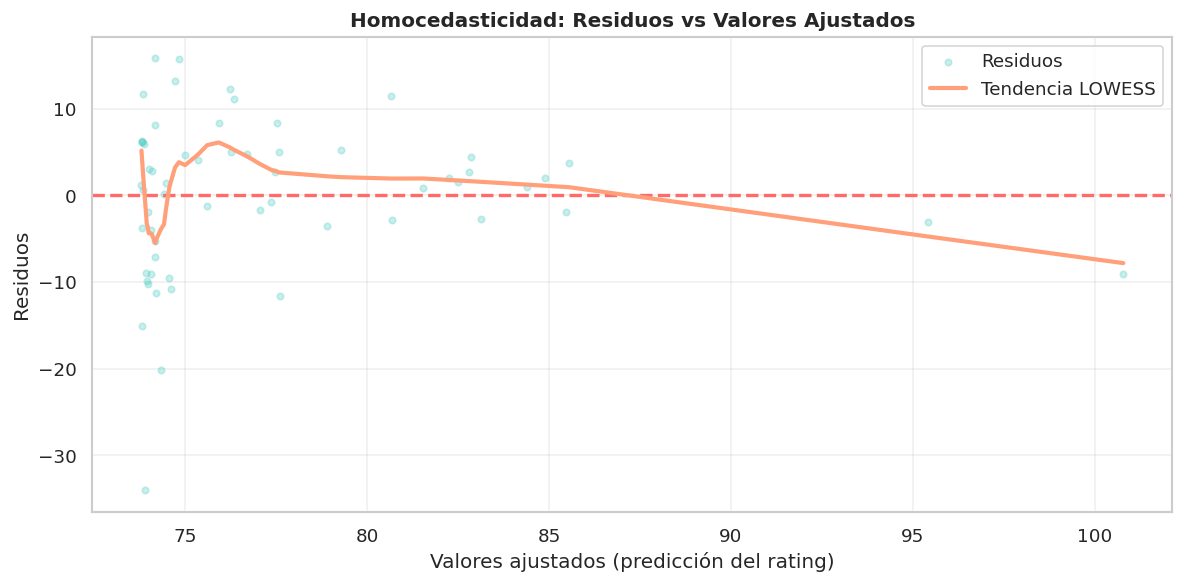


🔬 Test de Breusch-Pagan (Homocedasticidad):
   Estadístico LM : 2.1800
   p-value        : 0.139815
   Conclusión     : ✅ Se cumple homocedasticidad


In [23]:
# ── CELDA 15: Homocedasticidad (modelo simple) ───────────────

# Residuos y valores ajustados del modelo OLS
residuos_ols  = modelo_ols_simple.resid
ajustados_ols = modelo_ols_simple.fittedvalues

plt.figure(figsize=(10, 5))

# Scatter residuos vs predicciones
plt.scatter(ajustados_ols, residuos_ols,
            alpha=0.30, s=15, color='#4ecdc4',
            label='Residuos')

# Línea horizontal en 0
plt.axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)

# Línea suavizada LOWESS
lowess = sm.nonparametric.lowess(residuos_ols, ajustados_ols, frac=0.3)
plt.plot(lowess[:, 0], lowess[:, 1],
         color='#ffa07a', linewidth=2.5,
         label='Tendencia LOWESS')

plt.xlabel('Valores ajustados (predicción del rating)', fontsize=12)
plt.ylabel('Residuos', fontsize=12)

plt.title('Homocedasticidad: Residuos vs Valores Ajustados',
          fontsize=12, fontweight='bold')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

# Guardar imagen
import os
os.makedirs('../data/graficas', exist_ok=True)

plt.savefig('../data/graficas/homocedasticidad_videojuegos.png',
            dpi=150, bbox_inches='tight')

plt.show()


# ── Test de Breusch-Pagan ─────────────────

lm, lm_p, fval, fp = het_breuschpagan(
    residuos_ols,
    modelo_ols_simple.model.exog
)

print(f"\n🔬 Test de Breusch-Pagan (Homocedasticidad):")
print(f"   Estadístico LM : {lm:.4f}")
print(f"   p-value        : {lm_p:.6f}")

if lm_p > 0.05:
    print("   Conclusión     : ✅ Se cumple homocedasticidad")
else:
    print("   Conclusión     : ⚠️ Se detecta heterocedasticidad")

In [25]:
# ── CELDA 16: Preparación y entrenamiento — modelo múltiple ──

# Asegurar copia para evitar SettingWithCopyWarning
df_clean = df_clean.copy()

# Crear variables adicionales
df_clean.loc[:, 'anio'] = df_clean['fecha_lanzamiento'].dt.year
df_clean.loc[:, 'log_votos'] = np.log1p(df_clean['rating_count'])

# Eliminar posibles nulos en nuevas variables
df_clean = df_clean.dropna(subset=['anio'])

# Features del modelo múltiple
FEATURES = ['rating_count', 'log_votos', 'anio']

# Variables
X_multi = df_clean[FEATURES].values
y = df_clean['rating'].values

# Split
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.20, random_state=42
)

# Modelo
modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m, y_train_m)

# Predicción
y_pred_multi = modelo_multi.predict(X_test_m)

# Resultados
print(f"Intercepto β₀ : {modelo_multi.intercept_:.4f}")

for feat, coef in zip(FEATURES, modelo_multi.coef_):
    print(f"Coeficiente {feat:>15} : {coef:.6f}")

Intercepto β₀ : -478.3376
Coeficiente    rating_count : 0.007847
Coeficiente       log_votos : 2.213378
Coeficiente            anio : 0.270685


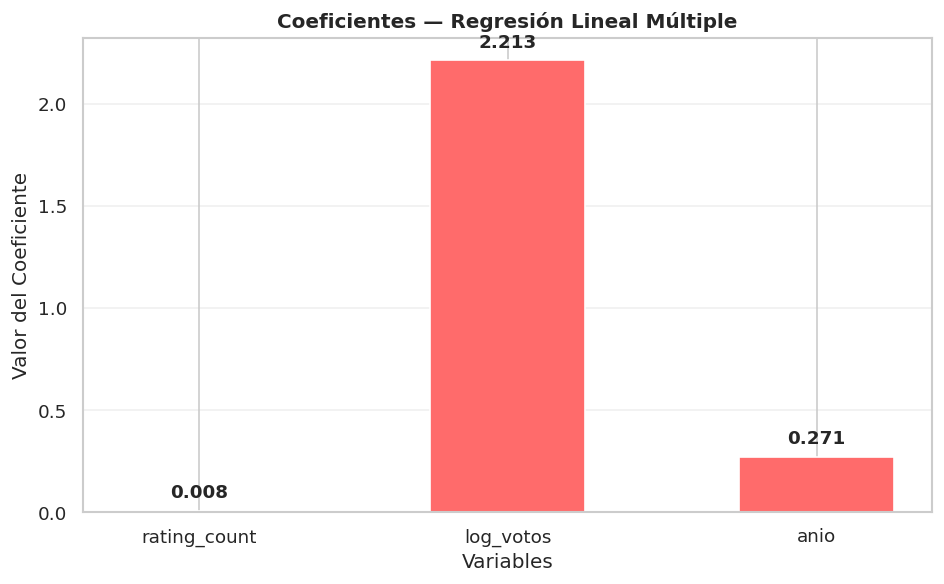

In [26]:
# ── CELDA 17: Gráfica de coeficientes ────────────────────────

import os
os.makedirs('../data/graficas', exist_ok=True)

# Colores según signo del coeficiente
colores = ['#ff6b6b' if c > 0 else '#4ecdc4' for c in modelo_multi.coef_]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(FEATURES, modelo_multi.coef_,
              color=colores, edgecolor='white', width=0.5)

# Línea base en 0
ax.axhline(0, color='gray', linestyle='--', linewidth=1)

ax.set_title('Coeficientes — Regresión Lineal Múltiple',
             fontsize=12, fontweight='bold')

ax.set_ylabel('Valor del Coeficiente')
ax.set_xlabel('Variables')

# Etiquetas de valores en barras
for bar, coef in zip(bars, modelo_multi.coef_):
    offset = 0.02 * max(abs(modelo_multi.coef_))  # dinámico (mejor que fijo)
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (offset if coef >= 0 else -offset),
            f'{coef:.3f}',
            ha='center',
            va='bottom' if coef >= 0 else 'top',
            fontsize=11,
            fontweight='bold')

ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

# Guardar imagen
plt.savefig('../data/graficas/coeficientes_modelo_multiple.png',
            dpi=150, bbox_inches='tight')

plt.show()

In [27]:
# ── CELDA 18: Métricas — modelo múltiple ─────────────────────

r2_m   = r2_score(y_test_m, y_pred_multi)
mse_m  = mean_squared_error(y_test_m, y_pred_multi)
rmse_m = np.sqrt(mse_m)
mae_m  = mean_absolute_error(y_test_m, y_pred_multi)

print("=" * 50)
print("📊 MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE")
print("=" * 50)

print(f"R²   (coef. de determinación) : {r2_m:.4f}  ({r2_m*100:.2f}%)")
print(f"MSE  (error cuadrático medio) : {mse_m:.4f}")
print(f"RMSE (raíz del MSE)           : {rmse_m:.4f}")
print(f"MAE  (error absoluto medio)   : {mae_m:.4f}")

print("=" * 50)

📊 MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE
R²   (coef. de determinación) : -0.1462  (-14.62%)
MSE  (error cuadrático medio) : 48.1857
RMSE (raíz del MSE)           : 6.9416
MAE  (error absoluto medio)   : 4.9304


In [28]:
# ── CELDA 19: OLS statsmodels — modelo múltiple ──────────────

# Variable independiente (X) + constante
X_ols_m = sm.add_constant(df_clean[FEATURES])

# Variable dependiente (y)
y_ols_m = df_clean['rating']

# Ajustar modelo
modelo_ols_multi = sm.OLS(y_ols_m, X_ols_m).fit()

# Mostrar resumen
print(modelo_ols_multi.summary())


# ── INTERPRETACIÓN EN ESPAÑOL ────────────────────────────────

print("\n" + "="*60)
print("📊 INTERPRETACIÓN DEL MODELO OLS MÚLTIPLE")
print("="*60)

r2 = modelo_ols_multi.rsquared
p_values = modelo_ols_multi.pvalues

print(f"R²: {r2:.4f}")

print("\n📌 Significancia de variables:")
for var in FEATURES:
    p_val = p_values[var]
    if p_val < 0.05:
        print(f"✅ {var}: significativa (p = {p_val:.4f})")
    else:
        print(f"❌ {var}: no significativa (p = {p_val:.4f})")

print("\n📌 Conclusión:")
print("El modelo múltiple permite explicar mejor el rating que el modelo simple,")
print("considerando múltiples factores como popularidad y tiempo.")

                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.343
Model:                            OLS   Adj. R-squared:                  0.308
Method:                 Least Squares   F-statistic:                     9.736
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           2.88e-05
Time:                        23:34:40   Log-Likelihood:                -212.14
No. Observations:                  60   AIC:                             432.3
Df Residuals:                      56   BIC:                             440.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         -384.5394    270.333     -1.422   

In [29]:
# ── CELDA 20: VIF — Factor de Inflación de la Varianza ───────

# Usar dataset limpio
X_vif = df_clean[FEATURES].copy()

# Cálculo de VIF
vif_data = pd.DataFrame({
    "Variable": FEATURES,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

# Redondear
vif_data["VIF"] = vif_data["VIF"].round(3)

# Interpretación
vif_data["Criterio"] = vif_data["VIF"].apply(
    lambda v: "✅ Sin multicolinealidad (VIF < 5)"
              if v < 5
              else ("⚠️ Moderada (5 ≤ VIF < 10)"
                    if v < 10
                    else "❌ Severa (VIF ≥ 10)")
)

print("\n📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)")
print("=" * 60)
print(vif_data.to_string(index=False))
print("=" * 60)


📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
    Variable    VIF                          Criterio
rating_count  3.980 ✅ Sin multicolinealidad (VIF < 5)
   log_votos 20.688               ❌ Severa (VIF ≥ 10)
        anio 12.643               ❌ Severa (VIF ≥ 10)


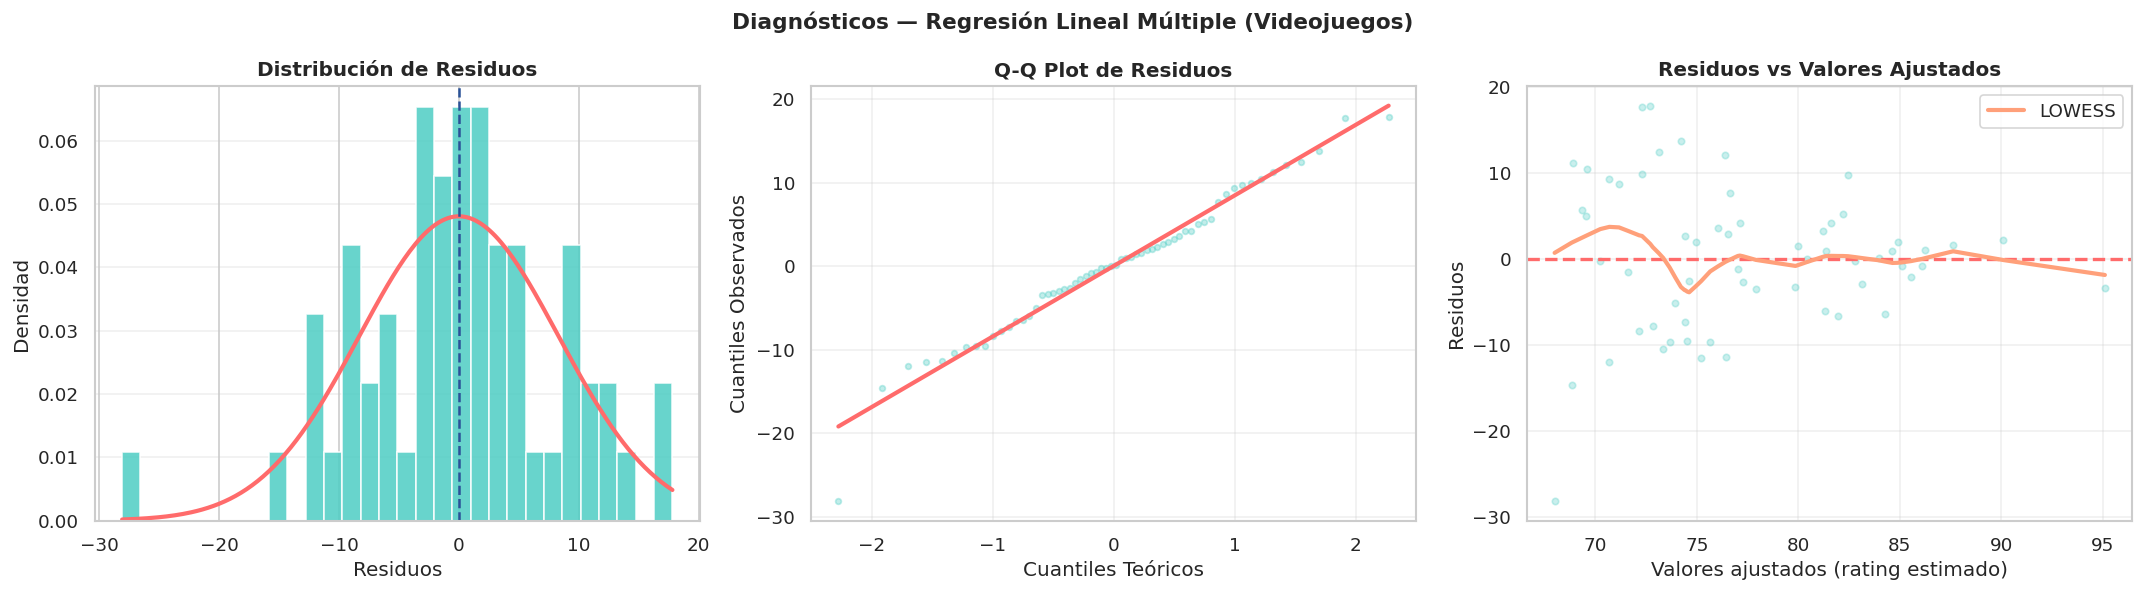


🔬 Test Shapiro-Wilk (Normalidad):
   p-value: 0.324493 → ✅ No se rechaza normalidad

🔬 Test Breusch-Pagan (Homocedasticidad):
   p-value: 0.000252 → ⚠️ Heterocedasticidad detectada


In [30]:
# ── CELDA 21: Diagnósticos completos — modelo múltiple ───────

import os
os.makedirs('../data/graficas', exist_ok=True)

# Residuos y valores ajustados
residuos_m  = modelo_ols_multi.resid.values
ajustados_m = modelo_ols_multi.fittedvalues.values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Diagnósticos — Regresión Lineal Múltiple (Videojuegos)',
             fontsize=13, fontweight='bold')

# ── Histograma de residuos
axes[0].hist(residuos_m, bins=30, color='#4ecdc4',
             edgecolor='white', density=True, alpha=0.85)

xr = np.linspace(residuos_m.min(), residuos_m.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos_m.mean(), residuos_m.std()),
             color='#ff6b6b', linewidth=2.5)

axes[0].axvline(0, color='#2a5298', linestyle='--')
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos')
axes[0].set_ylabel('Densidad')
axes[0].grid(axis='y', alpha=0.3)

# ── Q-Q Plot
(osm, osr), (s, i, _) = stats.probplot(residuos_m, dist='norm')
axes[1].scatter(osm, osr, alpha=0.35, s=12, color='#4ecdc4')

axes[1].plot(osm, s * np.array(osm) + i,
             color='#ff6b6b', linewidth=2.5)

axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles Observados')
axes[1].grid(alpha=0.3)

# ── Residuos vs Ajustados
axes[2].scatter(ajustados_m, residuos_m,
                alpha=0.30, s=15, color='#4ecdc4')

axes[2].axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)

lowess_m = sm.nonparametric.lowess(residuos_m, ajustados_m, frac=0.3)
axes[2].plot(lowess_m[:, 0], lowess_m[:, 1],
             color='#ffa07a', linewidth=2.5, label='LOWESS')

axes[2].set_title('Residuos vs Valores Ajustados', fontweight='bold')
axes[2].set_xlabel('Valores ajustados (rating estimado)')
axes[2].set_ylabel('Residuos')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()

plt.savefig('../data/graficas/diagnosticos_modelo_multiple.png',
            dpi=150, bbox_inches='tight')

plt.show()


# ── Tests estadísticos ─────────────────

muestra_m = (residuos_m if len(residuos_m) <= 5000
             else np.random.default_rng(42).choice(residuos_m, 5000,
                                                   replace=False))

stat_sw_m, p_sw_m = stats.shapiro(muestra_m)

lm_m, lm_p_m, _, _ = het_breuschpagan(
    modelo_ols_multi.resid,
    modelo_ols_multi.model.exog
)

print(f"\n🔬 Test Shapiro-Wilk (Normalidad):")
print(f"   p-value: {p_sw_m:.6f} → "
      f"{'✅ No se rechaza normalidad' if p_sw_m > 0.05 else '⚠️ Se rechaza normalidad'}")

print(f"\n🔬 Test Breusch-Pagan (Homocedasticidad):")
print(f"   p-value: {lm_p_m:.6f} → "
      f"{'✅ Homocedasticidad OK' if lm_p_m > 0.05 else '⚠️ Heterocedasticidad detectada'}")

In [31]:
# ── CELDA 22: Comparación final de modelos ───────────────────

comparacion = pd.DataFrame({
    'Modelo'   : ['Regresión Simple', 'Regresión Múltiple'],
    'Variables': [
        'rating_count',
        'rating_count + log_votos + anio'
    ],
    'R²'       : [round(r2, 4),    round(r2_m, 4)],
    'R² Aj.'   : [round(modelo_ols_simple.rsquared_adj, 4),
                  round(modelo_ols_multi.rsquared_adj, 4)],
    'RMSE'     : [round(rmse, 4),  round(rmse_m, 4)],
    'MAE'      : [round(mae, 4),   round(mae_m, 4)],
    'AIC'      : [round(modelo_ols_simple.aic, 2),
                  round(modelo_ols_multi.aic, 2)],
    'BIC'      : [round(modelo_ols_simple.bic, 2),
                  round(modelo_ols_multi.bic, 2)],
})

print("=" * 80)
print("              📊 COMPARACIÓN DE MODELOS")
print("=" * 80)

print(comparacion.to_string(index=False))

print("=" * 80)
print("\n📌 AIC/BIC más bajo → mejor equilibrio entre ajuste y complejidad")

              📊 COMPARACIÓN DE MODELOS
            Modelo                       Variables      R²  R² Aj.   RMSE    MAE    AIC    BIC
  Regresión Simple                    rating_count  0.3428  0.2478 6.9098 5.0881 435.35 439.53
Regresión Múltiple rating_count + log_votos + anio -0.1462  0.3076 6.9416 4.9304 432.27 440.65

📌 AIC/BIC más bajo → mejor equilibrio entre ajuste y complejidad


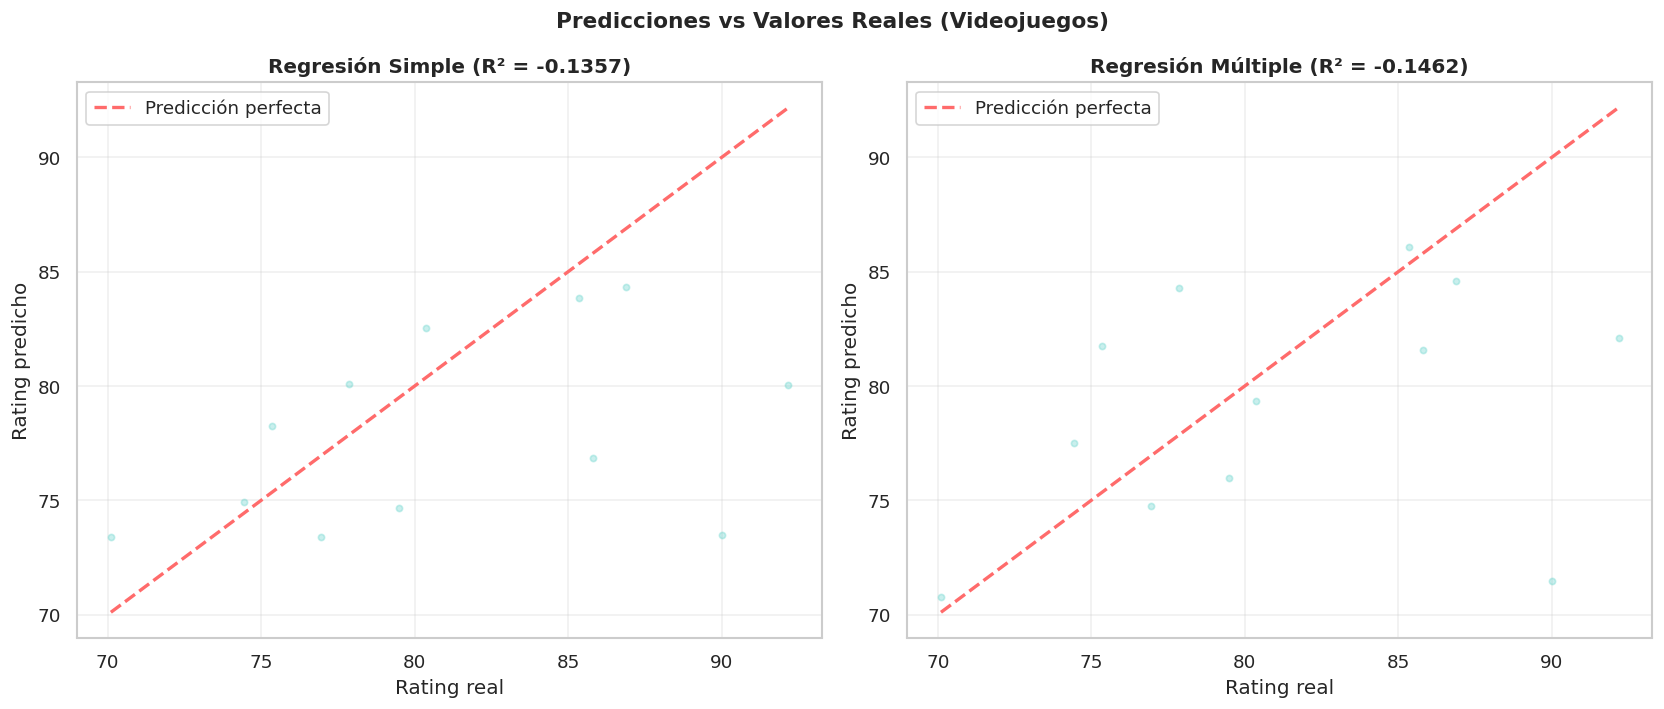

In [32]:
# ── CELDA 23: Predicciones vs Reales — ambos modelos ─────────

import os
os.makedirs('../data/graficas', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Predicciones vs Valores Reales (Videojuegos)',
             fontsize=13, fontweight='bold')

for ax, (y_real, y_pred, titulo) in zip(axes, [
    (y_test,   y_pred_simple, 'Regresión Simple'),
    (y_test_m, y_pred_multi,  'Regresión Múltiple'),
]):
    minval = min(y_real.min(), y_pred.min())
    maxval = max(y_real.max(), y_pred.max())

    ax.scatter(y_real, y_pred, alpha=0.30, s=14, color='#4ecdc4')

    # Línea de predicción perfecta
    ax.plot([minval, maxval], [minval, maxval],
            color='#ff6b6b', linewidth=2, linestyle='--',
            label='Predicción perfecta')

    r2_val = r2_score(y_real, y_pred)

    ax.set_title(f'{titulo} (R² = {r2_val:.4f})', fontweight='bold')

    ax.set_xlabel('Rating real')
    ax.set_ylabel('Rating predicho')

    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig('../data/graficas/predicciones_vs_reales_videojuegos.png',
            dpi=150, bbox_inches='tight')

plt.show()